In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows, savgol_filter
import pandas as pd
import datetime
from time import sleep
from glob import glob

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd

#import encosid

SIGNAL_DT_MS = 1. # 1ms
#gen = encosid.SignalGenerator("can0", 3)

In [3]:
gen = None
id = encosid.get_id("can0")

Found id #3


### Вспомогательные функции

In [28]:
# Устрание разрывов позиции (перескок на 2pi)
def stitch(Y, gap=2*np.pi, tol=1e-2):
  Y = Y.copy()
  for i in range(len(Y) - 1):
    dy = Y[i + 1] - Y[i]
    shift = dy # TODO include remainder
    if np.abs(dy) >= gap - tol:
      Y[i + 1:] -= shift
  return Y

def run_experiment(name, mode, T, X):
  modeval = None
  if mode == "pos":
    modeval = 0
  if mode == "vel":
    modeval = 1
  if mode == "trq":
    modeval = 2
  
  if modeval is None:
    raise RuntimeError("unknown mode")

  gen.set_mode(modeval)
  pos, vel, cur = map(np.array, gen.play_signal(X, SIGNAL_DT_MS))

  data = {"position": pos,
          "velocity": vel,
          "current":  cur,
          "target":   X,
          "time":     T}
  
  np.savez(f"experiments/{name}.npz", **data)

def load_experiment(name):
  data = np.load(f"experiments/{name}.npz")
  return data["time"], data["target"], data["position"], data["velocity"], data["current"]

def make_row(df, type, data, nlags):
  for i in range(nlags):
    df[f"q{type}_motor0_lag{i}"] = data[i: - nlags + i]

def make_dataset(dataname, nlags_, T, x, y, dy):
  nlags = nlags_ + 1
  timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M%S")

  df = pd.DataFrame()

  make_row(df, "act", x, nlags)
  make_row(df, "pos", y, nlags)
  make_row(df, "vel", dy, nlags)

  df["time"] = T[:-nlags]

  df.to_csv(f"datasets/{dataname}_{nlags_}_{timestamp}.csv", index=False)


## Проверка корректности позиций/скоростей

Расслабляем мотор, поворачиваем вал руками на 360 градусов, проверяем что данные с CAN корректны.
Проверям, что численная производная позиции совпадает с тем, что нам говорит мотор о скорости

In [3]:
T = np.arange(0, 8000, SIGNAL_DT_MS)
X = np.zeros_like(T)

run_experiment("datatest", "trq", T, X)

dY/dY_num ~ 1.0


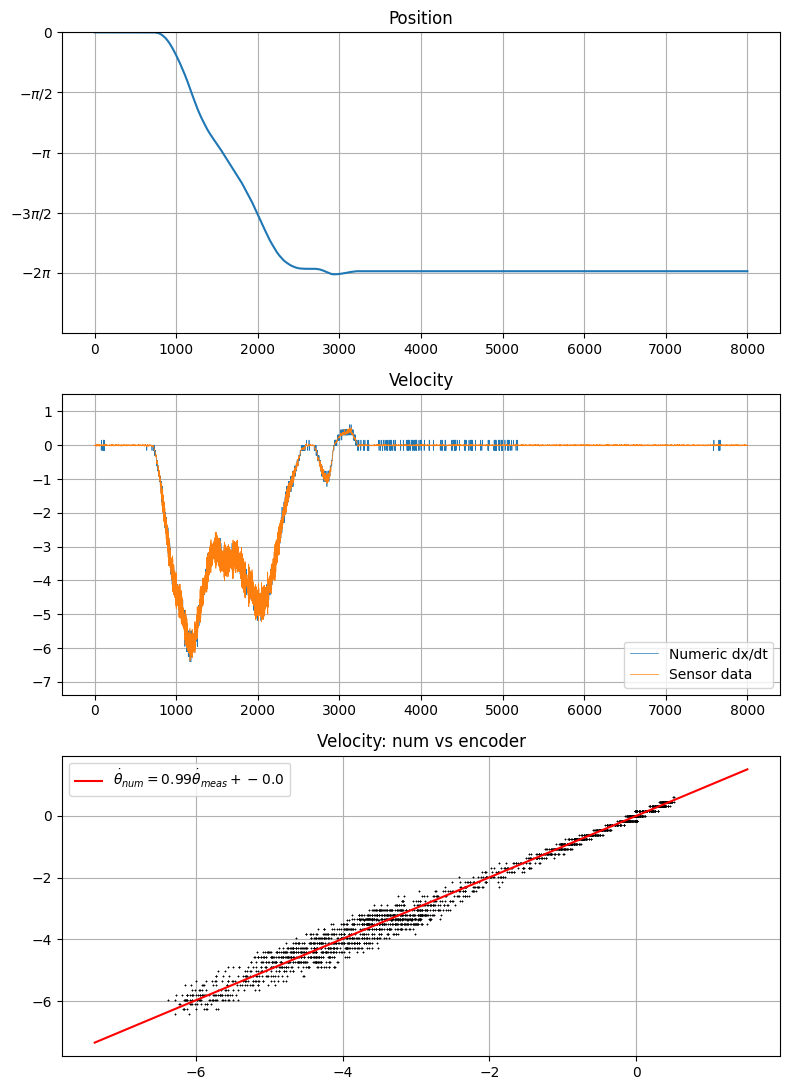

In [15]:
T, X, Y, dY, _ = load_experiment("datatest")

Y = stitch(Y - Y[0])

dY_lim = (np.min(dY) - 1, np.max(dY) + 1)

Y_lim = (-2.5 * np.pi, 0)

dY_num = np.zeros_like(Y)
dY_num[1:-1] = (Y[2:] - Y[:-2]) * 5e2 / SIGNAL_DT_MS

p = np.polyfit(dY_num, dY, 1)
print(f"dY/dY_num ~ {round(p[0], 2)}")

Y_ticks = [0, -np.pi/2, -np.pi, -1.5*np.pi, -2*np.pi]
Y_label = ["0", "$-\\pi / 2$", "$-\\pi$", "$-3\\pi / 2$", "$-2\\pi$"]

p = np.polyfit(dY, dY_num, 1)

fig, ax = plt.subplots(3, 1)
fig.set_size_inches(8, 11)

ax[0].plot(T, Y)
ax[0].set_title("Position")
ax[0].grid()
ax[0].set_yticks(Y_ticks, Y_label)
ax[0].set_ylim(*Y_lim)

ax[1].plot(T, dY_num, label="Numeric dx/dt", lw=.5)
ax[1].plot(T, dY, label="Sensor data", lw=.5)

ax[1].set_title("Velocity")
ax[1].set_ylim(*dY_lim)
ax[1].grid()
ax[1].legend()

dth = "\\dot{\\theta}"
num = "_{num}"
meas = "_{meas}"

ax[2].set_title("Velocity: num vs encoder")
ax[2].plot(dY, dY_num, 'kx', ms=.7)
ax[2].plot(dY_lim, np.polyval(p, dY_lim), 'r-', label=f"${dth + num} = {round(p[0], 2)} {dth + meas} + {round(p[1], 2)}$")
ax[2].grid()
ax[2].legend()

fig.tight_layout()
plt.show()

## Оценка armature

Оцениваем armature и максимальное ускорение. Это нужно для того, чтобы потом генерировать управляющие сигналы, НЕ выводящие мотор на максимальную скорость.
Аналогично измерению armature в tenso.ipynb

Эксперимент проводится со свободным валом.

In [18]:
PULSE_LEN_S = 3
AMPLITUDE = 6

pulse_len = int(1e3 * PULSE_LEN_S / SIGNAL_DT_MS)

X = np.zeros((3*pulse_len), dtype=np.float64)
X[pulse_len:-pulse_len] = AMPLITUDE

T = np.arange(0, 3 * pulse_len) * 1e-3 * SIGNAL_DT_MS

In [ ]:
run_experiment("armature_estimate", "trq", T, X)

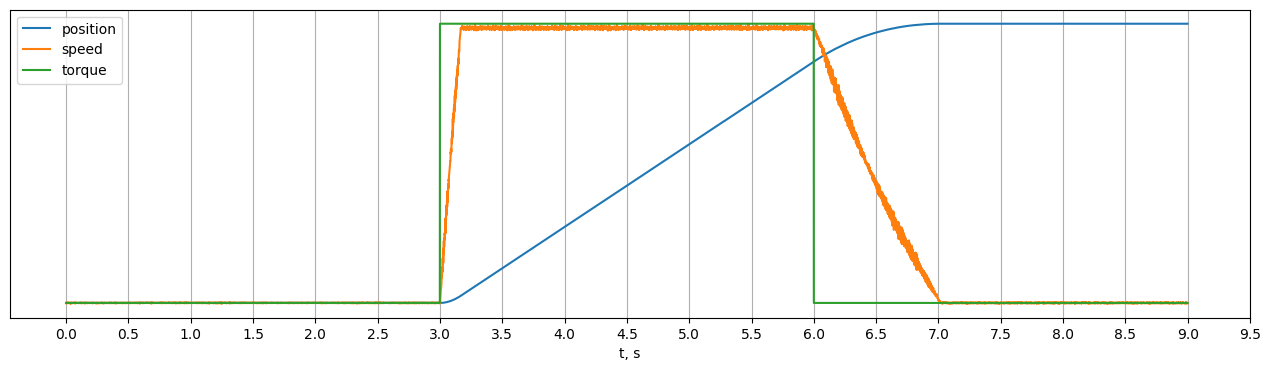

In [19]:
T, X, Y, dY, _ = load_experiment("armature_estimate")
Y = stitch(Y - Y[0])

plt.figure(figsize=(16, 4))
plt.plot(T, Y / np.max(Y), label="position")
plt.plot(T, dY / np.max(np.abs(dY)), label="speed")
#plt.plot(T[:-1], (Y[1:] - Y[:-1]) / SIGNAL_DT_MS * 1e3, label="speed, numeric")
plt.plot(T, X / np.max(np.abs(X)), label="torque")
plt.grid()
plt.legend()
ticks = np.arange(0, 10, .5)
plt.yticks([])
plt.xticks(ticks)
plt.xlabel("t, s")
plt.show()

In [20]:
VMAX = np.max(np.abs(dY))
TMAX = 20

print(f"vmax = {VMAX}")

wlen = 100
window = windows.hann(wlen)
norm = np.sum(window) * wlen * 1e-2 * SIGNAL_DT_MS

dY_smooth = np.convolve(dY, window / norm, mode='same')
ddY = (dY_smooth[2:] - dY_smooth[:-2]) * 5e2 / SIGNAL_DT_MS
where = (np.abs(ddY) > 5)
acc = (np.max(ddY, where=where, initial=0) - np.min(ddY, where=where, initial=0)) # rad / s^2
ARMATURE = (AMPLITUDE / acc)

print(f"armature ~ {ARMATURE}")

ACCMAX = TMAX / ARMATURE
print(f"accmax ~ {ACCMAX}")

vmax = 17.13309097290039
armature ~ 0.04694208503999513
accmax ~ 426.0569163674728


## Генерация возбуждения в виде гармоник

Генерируем сигнал скорости как суперпозицию Фурье-мод. Нормируем сигнал на максмальную скорость. После этого дифференцируем, устраняем разрывы скорости (для 
того нужен ACCMAX), домножаем на armature - и получаем сигнал на момент, который не выведет мотор выше макс. скорости

In [21]:
def gen_bins(M, Nmin, Nmax, rng: np.random.Generator):
  nbins = None
  if M == 1:
    nbins = 1
  else:
    nbins = rng.integers(1, M)
  
  bins = set()
  gen = lambda: rng.integers(Nmin, Nmax)
  for _ in range(nbins):
    val = gen()
    while val in bins:
      val = gen()
    bins.add(val)

  return np.array(list(bins))

def gen_random_harmonics(M, N, fmax, seed):
  fnyq = 1e3 / SIGNAL_DT_MS / 2
  F = np.linspace(-fnyq, fnyq, 2*N)

  rng = np.random.default_rng(seed=seed)

  binmax = N * (fmax / fnyq)
  if binmax > N: binmax = N

  bins = gen_bins(M, 0, binmax, rng)

  X = np.zeros((2 * N,), dtype=np.complex64)

  X.real[bins] = rng.random(len(bins))
  X.imag[bins] = rng.random(len(bins))

  X.real[2*N - bins] = X.real[bins]
  X.imag[2*N - bins] = -X.imag[bins]
  return F, X

VMAX_LIMIT = 0.95
def gen_signal(X, N):
  x = np.fft.ifft(X)
  T = 1e-3 * np.linspace(0, 2*N * SIGNAL_DT_MS, 2*N)
  return T, VMAX * VMAX_LIMIT * np.real(x) / np.max(np.abs(np.real(x)))

def extend_signal(T, x, n):
  new_x = np.ndarray((len(x) + 2*n), dtype=x.dtype)
  new_x[:n] = 0
  new_x[n: len(x) + n] = x.copy()
  new_x[-n:] = 0

  xl = x[0]
  dt = xl / ACCMAX
  dn = int(dt * 1000 / SIGNAL_DT_MS)

  new_x[n - dn:n] = xl * np.arange(0, dn) / dn

  xr = x[-1]
  dt = xr / ACCMAX
  dn = int(dt * 1000 / SIGNAL_DT_MS)

  new_x[-n: -n + dn] = xr * np.arange(0, dn)[::-1] / dn
  
  N = np.arange(1, n + 1)
  new_t = np.ndarray((len(x) + 2*n), dtype=T.dtype)
  new_t[:n] = -T[-1] * N[::-1] / len(T)
  new_t[n: len(T) + n] = T
  new_t[-n:] = T[-1] * (1 + N / len(T))

  return new_t, new_x

TORQUE_SIGNAL_FINE = 1.0
def make_torque_signal(T, v):
  dv = (v[2:] - v[:-2]) * 1e3 / (2 * SIGNAL_DT_MS)
  tau = ARMATURE * dv * TORQUE_SIGNAL_FINE
  return T[1:-1], tau

In [22]:
N = 4096*2
F, V = gen_random_harmonics(3, N, 5, 8)
T, v = gen_signal(V, N)
T, v = extend_signal(T, v, 2048)

T, x = make_torque_signal(T, v)

In [ ]:
run_experiment("harmonics", "trq", T, x)

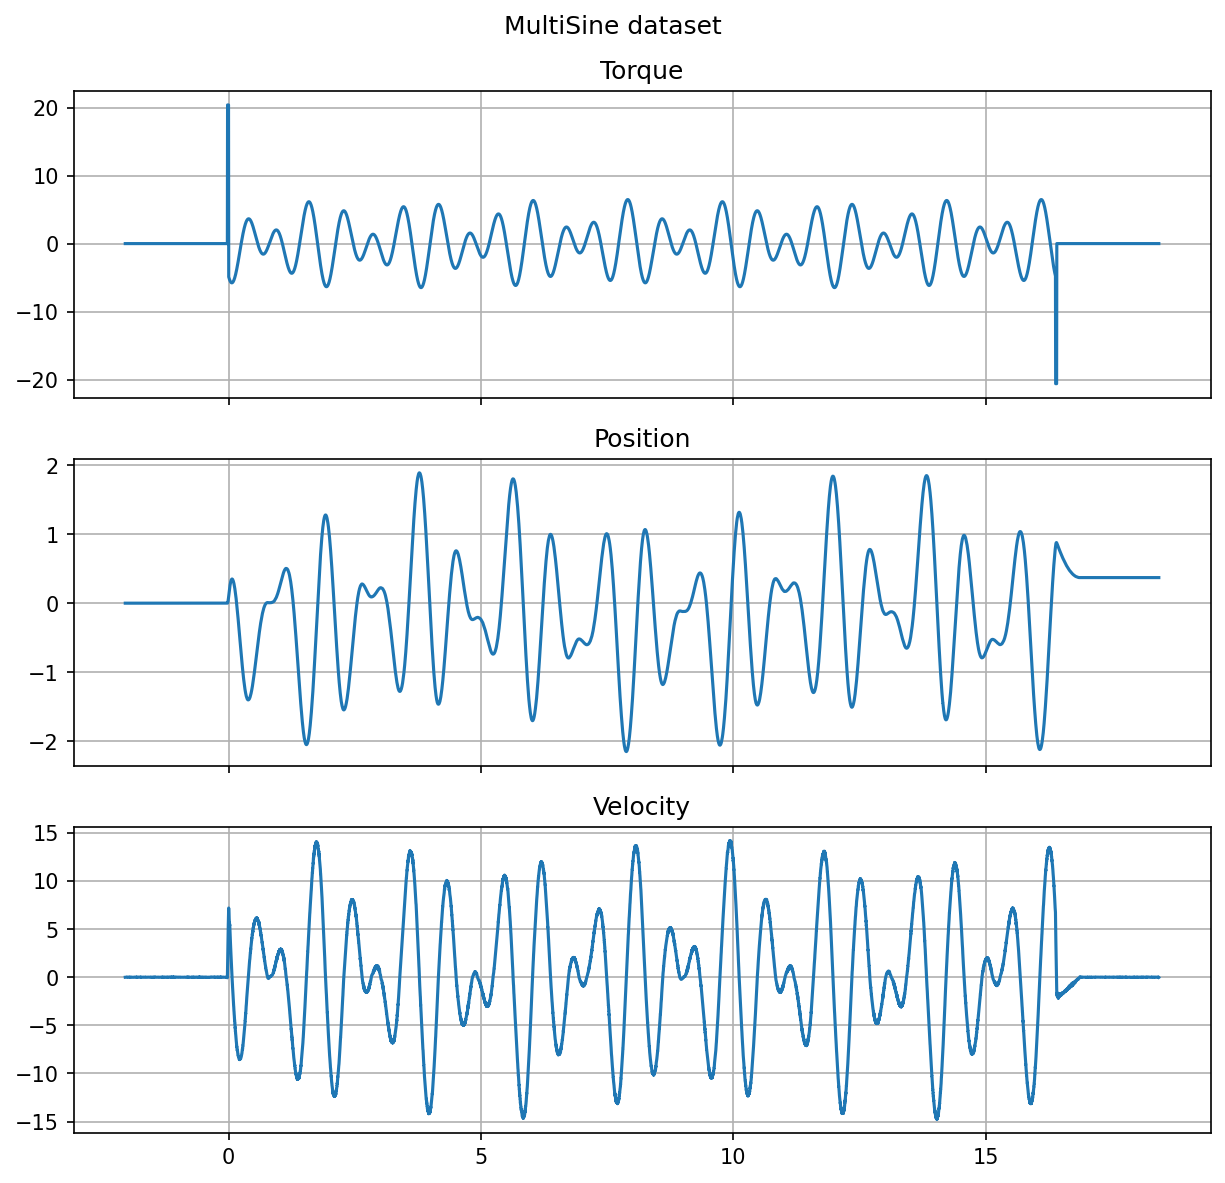

C:\Users\tndrd\AppData\Local\Temp\ipykernel_12888\896838626.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"q{type}_motor0_lag{i}"] = data[i: - nlags + i]
C:\Users\tndrd\AppData\Local\Temp\ipykernel_12888\896838626.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["time"] = T[:-nlags]


In [29]:
T, x, y, dy, cur = load_experiment("harmonics")

y = stitch(y - y[0])
dy = savgol_filter(dy, 10, 3)

dy_num = np.zeros_like(y)
dy_num[1:-1] = (y[2:] - y[:-2]) * 5e2 / SIGNAL_DT_MS

fig, ax = plt.subplots(3, 1, sharex=True)
#fig.set_size_inches(7, 10)
fig.set_dpi(150)

from scipy.signal import medfilt
cur = medfilt(cur, 101)

ax[0].plot(T, x, label="Target")
#ax[0].plot(T, cur * 4.16, label="Measured")

ax[0].grid()
ax[0].set_title("Torque")

ax[1].plot(T, y)
ax[1].set_title("Position")
ax[1].grid()

ax[2].plot(T, dy)
ax[2].set_title("Velocity")
ax[2].grid()

fig.set_size_inches(8.27, 8)

plt.suptitle("MultiSine dataset")
fig.tight_layout()

plt.show()

make_dataset("harmonics", 100, T, x, y, dy)

## Генерация возбуждения в виде импульсов

Генерируем набор импульсов случайной амплитуды. 
Длительность импульса с заданной амплитудой ограничиваем из оценки скорости, достигаемой за время возбуждения:

$$v \leq (amplitude / armature) \cdot t \leq v_{max}$$

Интервал между импульсами делаем >= время остановки двигателя под действием силы трения из v=vmax. Это время определяется в пункте "Оценка armature". Таким образом, каждый импульс начинается из состояния v=0.
Воспроизводим сигнал. После этого вырезаем из сигнала участки v $\approx 0$.

In [30]:
PULSE_FINE = 1.0
def make_pulses(tdown_min, amplitude_max, time, seed):
    T = np.arange(0, time, 1e-3 * SIGNAL_DT_MS)
    X = np.zeros_like(T)

    rng = np.random.default_rng(seed=seed)

    rand = lambda: rng.random(1)[0]

    i = 0
    while i < len(T):
        amplitude = rand() * amplitude_max
        sign = 1 - 2 * (rand() > .5)

        tmax = ARMATURE * VMAX * PULSE_FINE / amplitude
        samples_up = int(rand() * tmax * 1e3 / SIGNAL_DT_MS)

        tdown = tdown_min * (1 + rand())
        samples_down = int(tdown * 1e3 / SIGNAL_DT_MS)

        X[i + samples_down:i + samples_down + samples_up] = amplitude * sign

        i += samples_up + samples_down
    return T, X

# Strip time intervals where v=0
def strip_pulses(time, trq, pos, vel, cur):
  wlen = 100
  vel_avg = np.convolve(vel, np.ones(wlen) / wlen, mode='same')

  ifiltered = np.where(np.abs(vel_avg) > 0.005)

  pos = pos[ifiltered]
  vel = vel[ifiltered]
  trq = trq[ifiltered]
  cur = cur[ifiltered]

  time = stitch(time[ifiltered], 2e-3 * SIGNAL_DT_MS, 1e-4)
  time -= time[0]

  pos -= pos[0]

  return time, trq, pos, vel, cur

In [25]:
T, X = make_pulses(2, 20, 30, 1)
run_experiment("pulses", "trq", T, X)

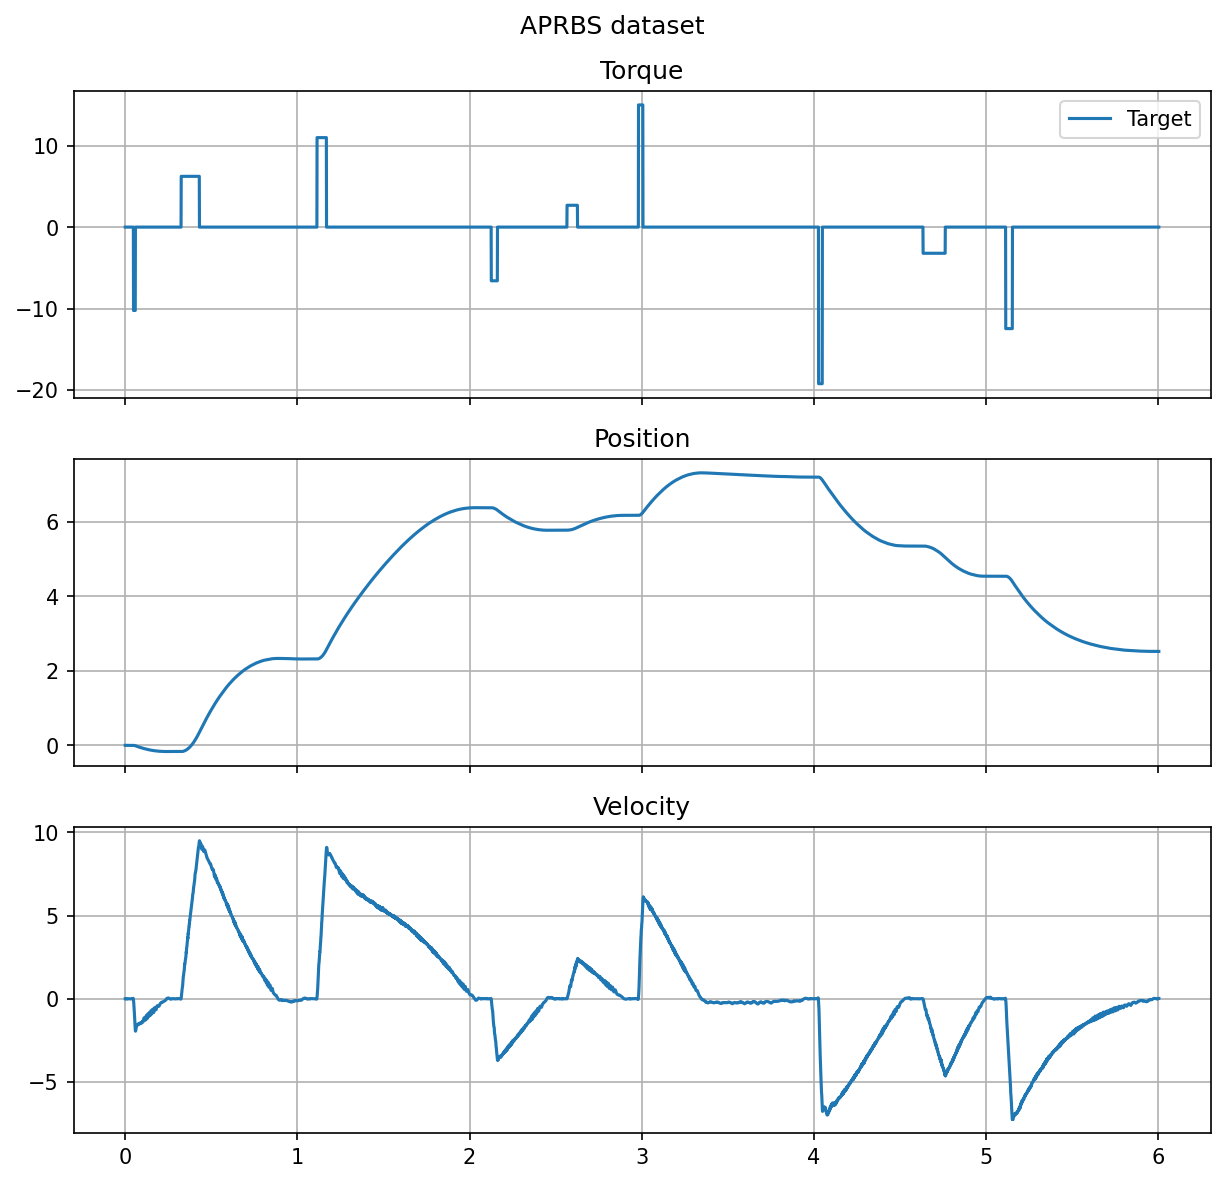

In [31]:
from scipy.signal import medfilt

T, x, y, dy, cur = load_experiment("pulses")

dy = savgol_filter(dy, 10, 3)
cur = medfilt(cur, 11)
y = stitch(y - y[0])

T, x, y, dy, cur = strip_pulses(T, x, y, dy, cur)

fig, ax = plt.subplots(3, 1, sharex=True)
fig.set_dpi(150)

ax[0].plot(T, x, label="Target")
#ax[0].plot(T, cur * 4.16, label="Measured")

ax[0].grid()
ax[0].legend()
ax[0].set_title("Torque")

ax[1].plot(T, y)
ax[1].set_title("Position")
ax[1].grid()

ax[2].plot(T, dy)
ax[2].set_title("Velocity")
ax[2].grid()

fig.set_size_inches(8.27, 8)
plt.suptitle("APRBS dataset")
fig.tight_layout()

#make_dataset("pulses", 100, T, x, y, dy)

# Результаты обучения

<>:46: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:46: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\tndrd\AppData\Local\Temp\ipykernel_12888\2095381303.py:46: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plot_key(ax[3], 'damping', "damping,~ Nm \cdot s / rad")
C:\Users\tndrd\AppData\Local\Temp\ipykernel_12888\2095381303.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


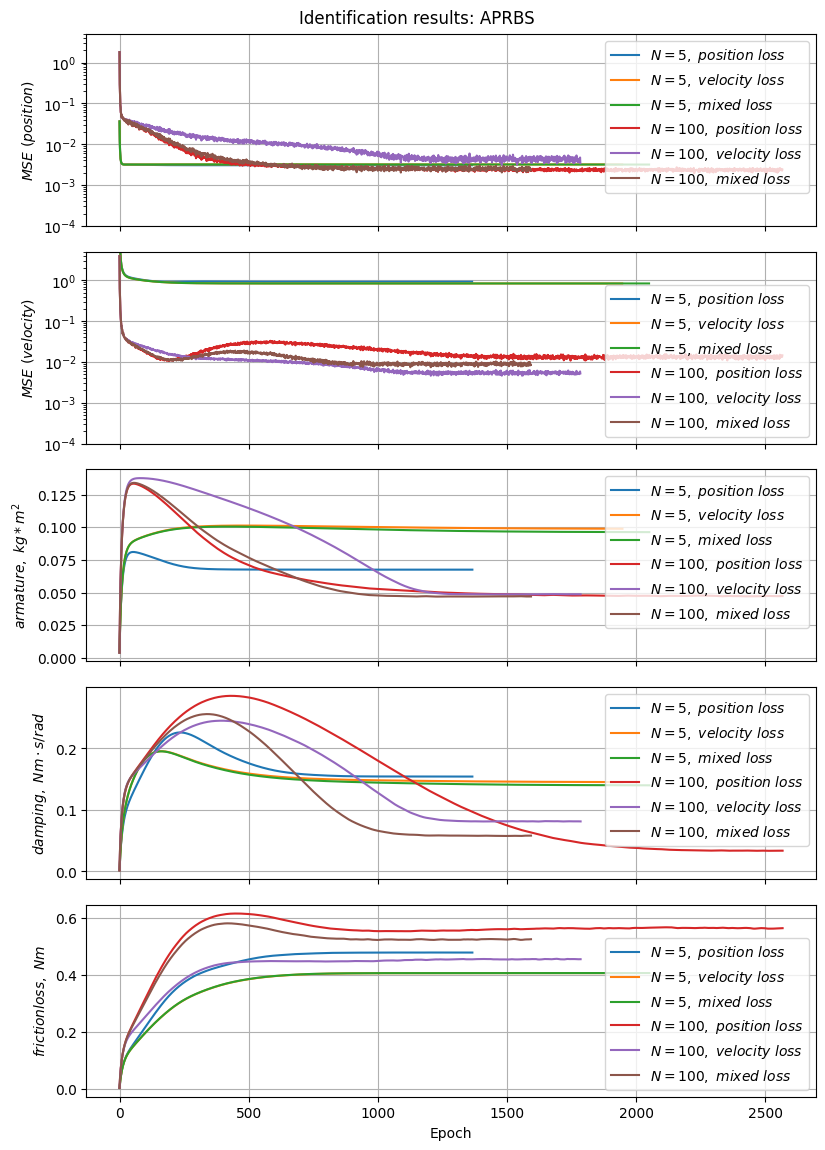

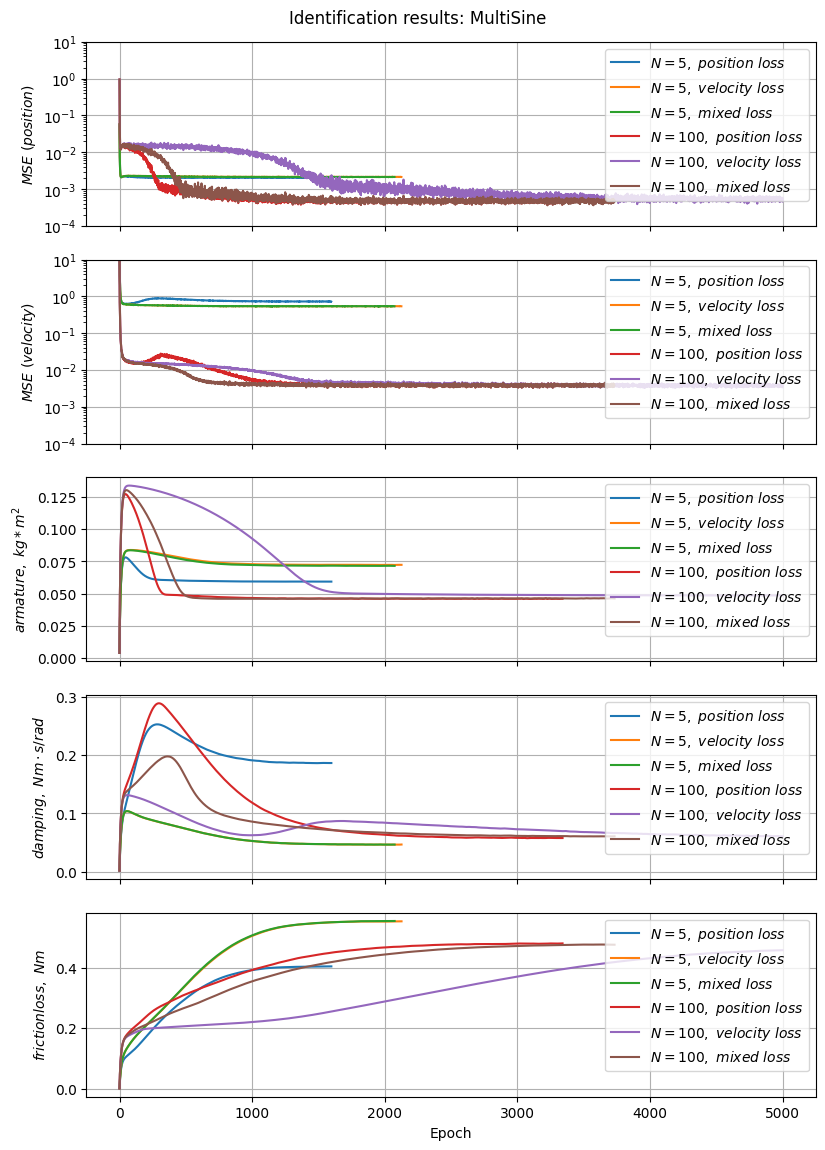

In [34]:
def load_result(loss_scale, numlags, tag, path):
    import glob
    name = path
    path = glob.glob(f'runs/raw/encos.{path}/**/events.out.tfevents*', recursive=True)

    assert len(path) == 1
    ea = EventAccumulator(path[0])
    ea.Reload()

    data = {'loss_full': 'train/loss',
            'loss_qpos': 'train/loss_qpos',
            'loss_qvel': 'train/loss_qvel',
            'grad_norm': 'train/grad_norm',
            'armature': 'params/changers/chg_0/armature',
            'damping': 'params/changers/chg_1/damping',
            'frictionloss': 'params/changers/chg_2/frictionloss'}
    
    for key, value in data.items():
        data[key] = np.array([s.value for s in ea.Scalars(value)])

    data['loss_scale'] = loss_scale
    data['numlags'] = numlags
    data['tag'] = tag
    data['path'] = name

    return data

def plot_group(name, group):
    def plot_key(axis, key, ylabel, scale=False):
      axis.set_ylabel(f"${ylabel}$")
      for data in group:
          label = f"$N={data['numlags']}, ~{data['tag']}$"
          if scale:
            axis.plot(data[key] / data['numlags'], label=label)
            axis.set_ylim(1e-4, data['loss_scale'])
            axis.set_yscale('log', base=10)
          else:
            axis.plot(data[key], label=label)
      axis.grid()
      axis.legend()
    
    fig, ax = plt.subplots(5, 1, sharex=True)
    plot_key(ax[0], 'loss_qpos', 'MSE ~(position)', True)
    plot_key(ax[1], 'loss_qvel', 'MSE~ (velocity)', True)
    plot_key(ax[2], 'armature', "armature,~ kg*m^2")
    plot_key(ax[3], 'damping', "damping,~ Nm \cdot s / rad")
    plot_key(ax[4], 'frictionloss', 'frictionloss,~ Nm')
    
    ax[4].set_xlabel("Epoch")

    plt.suptitle(name)
    fig.set_size_inches(8.27, 11.69)
    fig.tight_layout()
    fig.show()

group1 = [load_result(5, 5, 'position~ loss', 'pulses_5_pos'),
          load_result(5, 5, 'velocity~ loss', 'pulses_5_vel'),
          load_result(5, 5, 'mixed~ loss', 'pulses_5_mix'),
          load_result(5, 100, 'position~ loss', 'pulses_100_pos'),
          load_result(5, 100, 'velocity~ loss', 'pulses_100_vel'),
          load_result(5, 100, 'mixed~ loss', 'pulses_100')
  ]

group2 = [load_result(10, 5, 'position~ loss', 'harmonics_5_pos'),
          load_result(10, 5, 'velocity~ loss', 'harmonics_5_vel'),
          load_result(10, 5, 'mixed~ loss', 'harmonics_5_mix'),
          load_result(10, 100, 'position~ loss', 'harmonics_100_pos'),
          load_result(10, 100, 'velocity~ loss', 'harmonics_100_vel'),
          load_result(10, 100, 'mixed~ loss', 'harmonics_100'),
  ]

plot_group('Identification results: APRBS', group1)
plot_group('Identification results: MultiSine', group2)

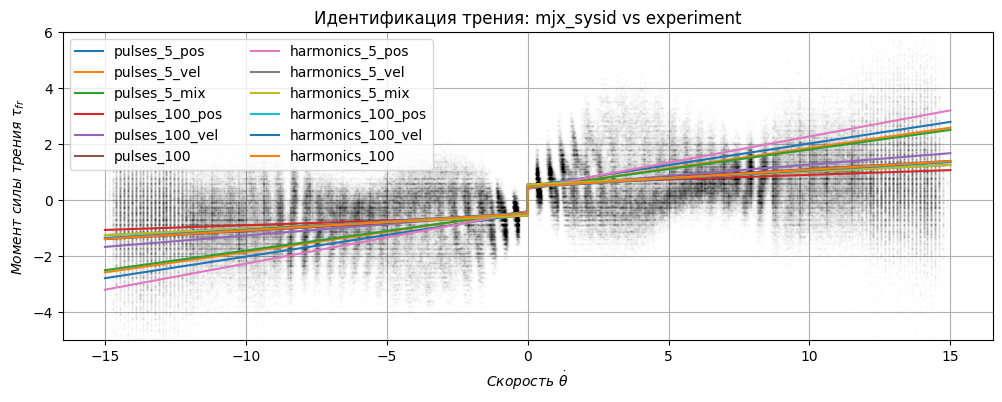

,dataset,N,tag,armature,damping,frictionloss
0,APRBS,5,position,0.067,0.154,0.478
1,APRBS,5,velocity,0.099,0.145,0.406
2,APRBS,5,mixed,0.096,0.140,0.406
3,APRBS,100,position,0.047,0.034,0.563
4,APRBS,100,velocity,0.049,0.081,0.454
5,APRBS,100,mixed,0.047,0.058,0.525
6,MultiSine,5,position,0.059,0.187,0.404
7,MultiSine,5,velocity,0.072,0.047,0.552
8,MultiSine,5,mixed,0.072,0.047,0.553
9,MultiSine,100,position,0.046,0.058,0.480


In [36]:
data = np.load("friction_result.npz")

df = pd.DataFrame()

keys = ['dataset', 'N', 'tag', 'armature', 'damping', 'frictionloss']

for key in keys:
    df[key] = []

datasets = []
Ns = []
armatures = []
dampings = []
frictionlosses = []
tags = []

Tq = data["torque"]
V = data["vel"]

plt.figure(figsize=(12, 4))
plt.plot(V, Tq, 'ko', ms=.5, alpha=.02)
plt.grid()

for group in [group1, group2]:
    for entry in group:
        dataset = entry["path"]
        N = entry['numlags']
        armature_ = round(entry['armature'][-1], 3)
        damping_ = round(entry["damping"][-1], 3)
        frictionloss_ = round(entry["frictionloss"][-1], 3)

        armature = entry['armature'][-1]
        damping = entry["damping"][-1]
        frictionloss = entry["frictionloss"][-1]

        if (dataset[0] == 'h'):
            datasets.append('MultiSine')
        else:
            datasets.append("APRBS")
        Ns.append(N)
        tags.append(entry['tag'][:-6])
        armatures.append(armature_)
        dampings.append(damping_)
        frictionlosses.append(frictionloss_)

        X = [-15, -1e-3, 1e-3, 15]

        def val(x):
            if x > 0:
                return  frictionloss + damping * x
            else: return -frictionloss + damping * x
                
        y = list(map(val, X))

        plt.plot(X, y, label=entry["path"])


plt.ylim(-5, 6)
plt.legend(ncol=2)
plt.ylabel("$Момент~ силы~ трения ~\\tau_{fr}$")
plt.xlabel("$Скорость~ \\dot{\\theta}$")
plt.title("Идентификация трения: mjx_sysid vs experiment")
plt.show()

df['dataset'] = datasets
df['N'] = Ns
df['tag'] = tags
df['armature'] = armatures
df['frictionloss'] = frictionlosses
df['damping'] = dampings

df.to_excel("results.xlsx")
df